In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("loan_approval_data.csv")
# df.head()
# df.info()
# df.isnull().sum()

# DATA CLEANING

In [3]:
# Handling missing values
numerical_cols = df.select_dtypes(include=["float64"]).columns
categorial_cols = df.select_dtypes(include=["object"]).columns

# numerical_cols
# categorial_cols
# numerical_cols.size + categorial_cols.size
# df.shape[1]

# df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())
from sklearn.impute import SimpleImputer
num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

catg_imp = SimpleImputer(strategy="most_frequent")
df[categorial_cols] = catg_imp.fit_transform(df[categorial_cols])

# df.isnull().sum()
# df.count()

# EDA

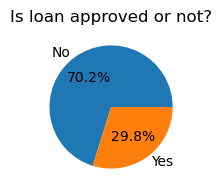

In [4]:
# How balance our classes are?
classes_count = df["Loan_Approved"].value_counts()
plt.figure(figsize=(2,2))
plt.pie(classes_count,labels=["No","Yes"],autopct="%1.1f%%")
plt.title("Is loan approved or not?")
plt.show()

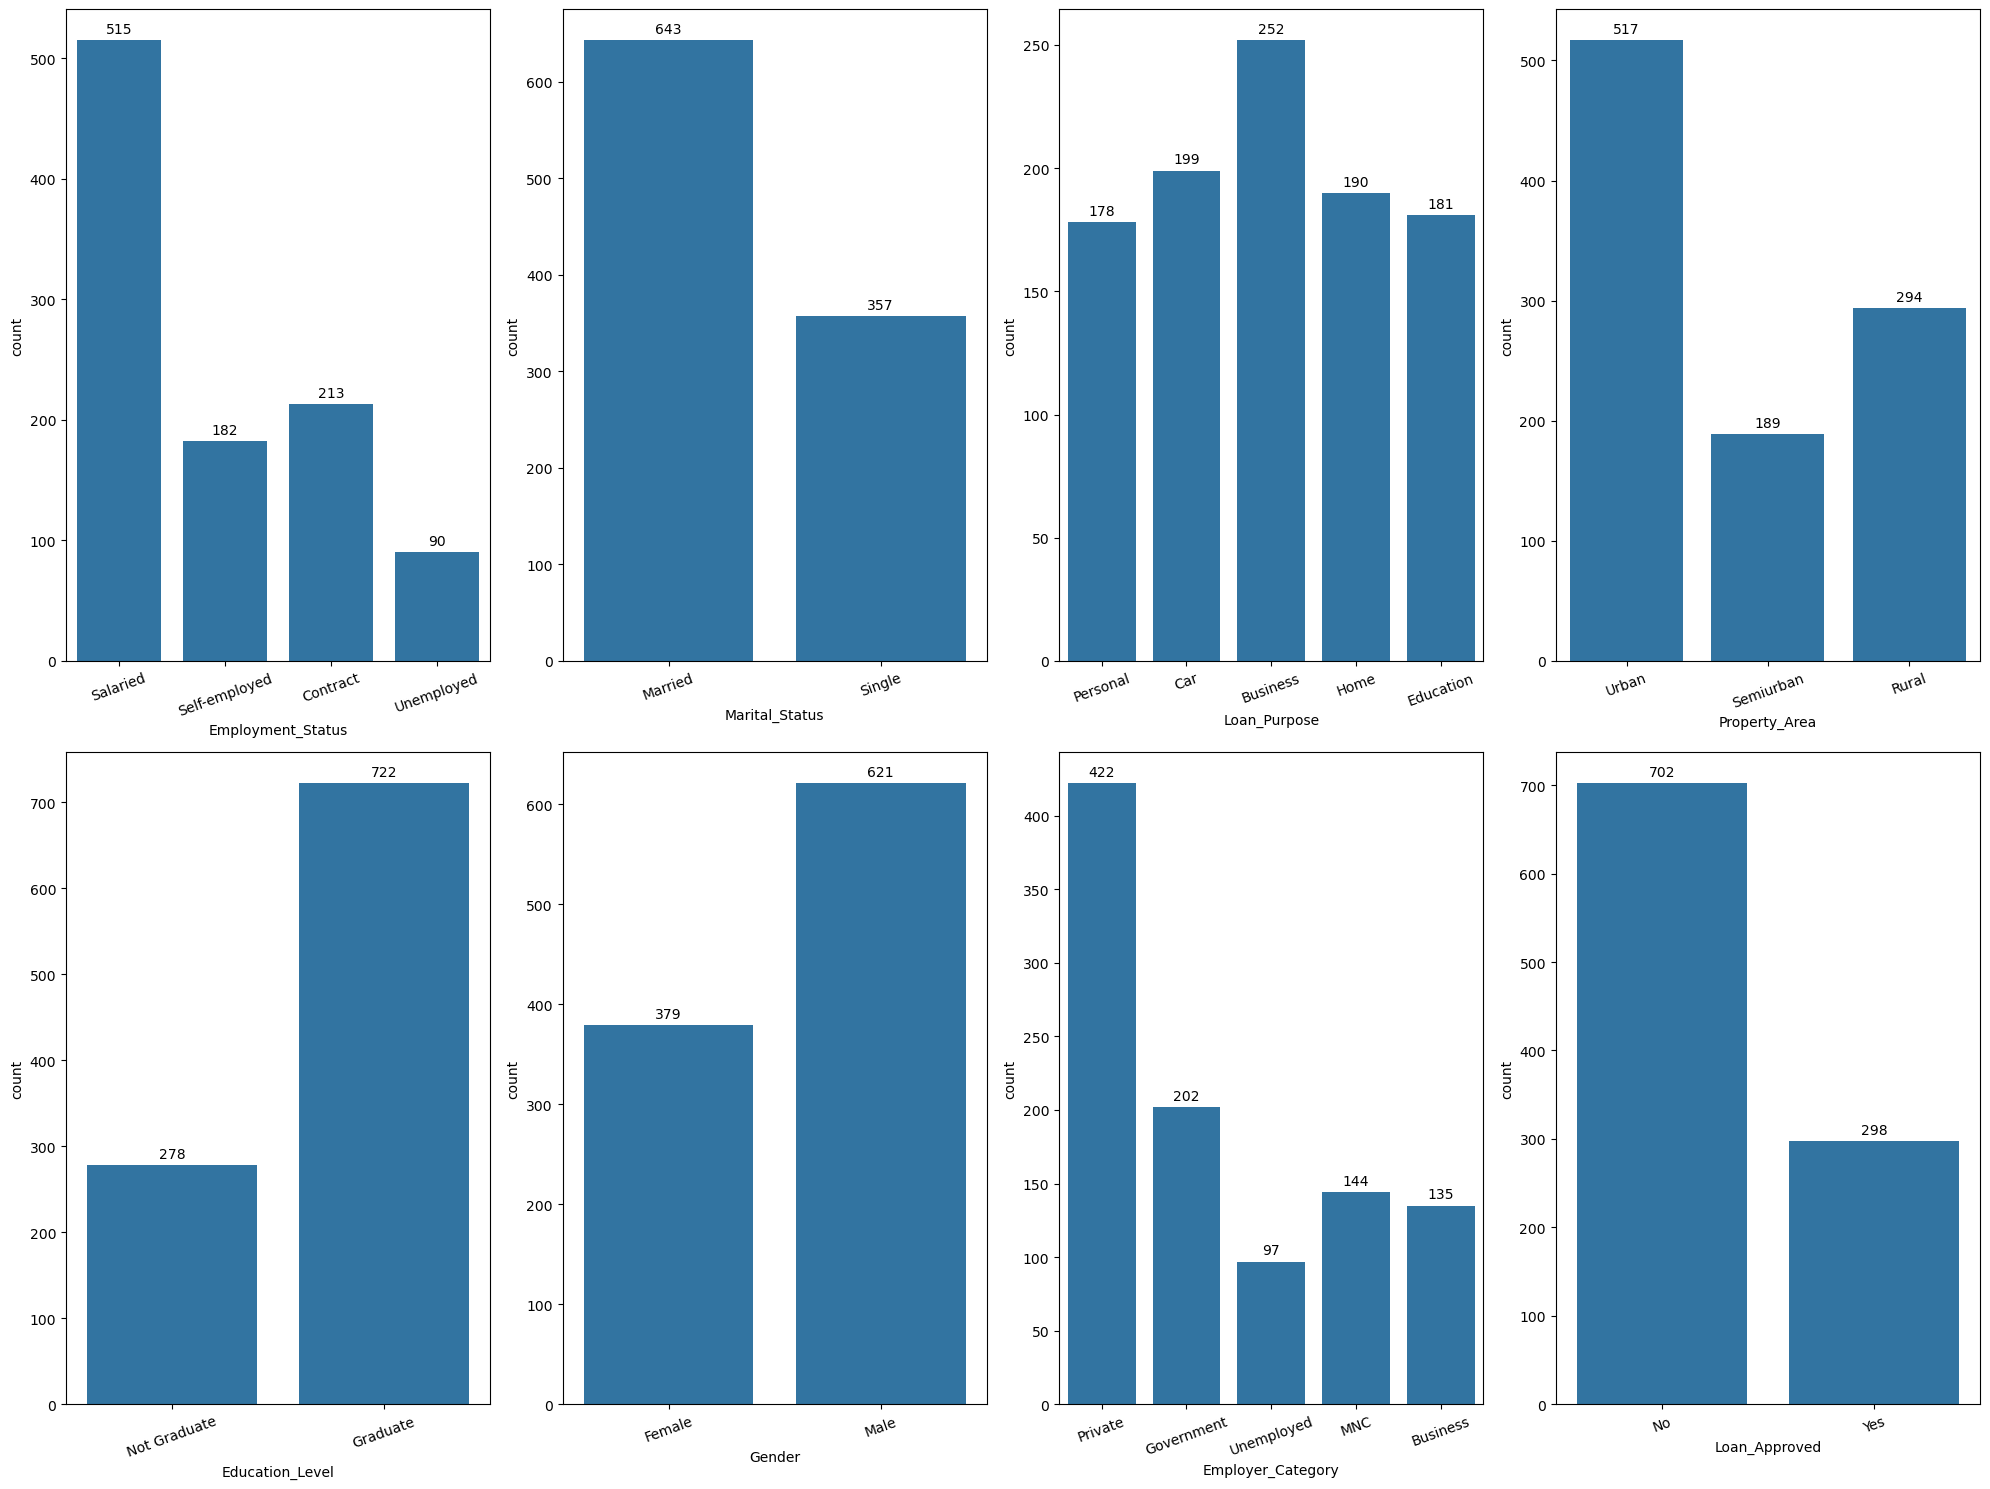

In [5]:
# analyze categories
fig, axes = plt.subplots(2,4,figsize=(20,15))
for col,ax in zip(categorial_cols, axes.flat):
    sns.countplot(ax=ax,data=df,x=col)

    for container in ax.containers:
        ax.bar_label(container,padding=3)  # padding adds a tiny space above the bar

    ax.tick_params(axis="x", labelrotation=20)
    
plt.tight_layout()
plt.show()

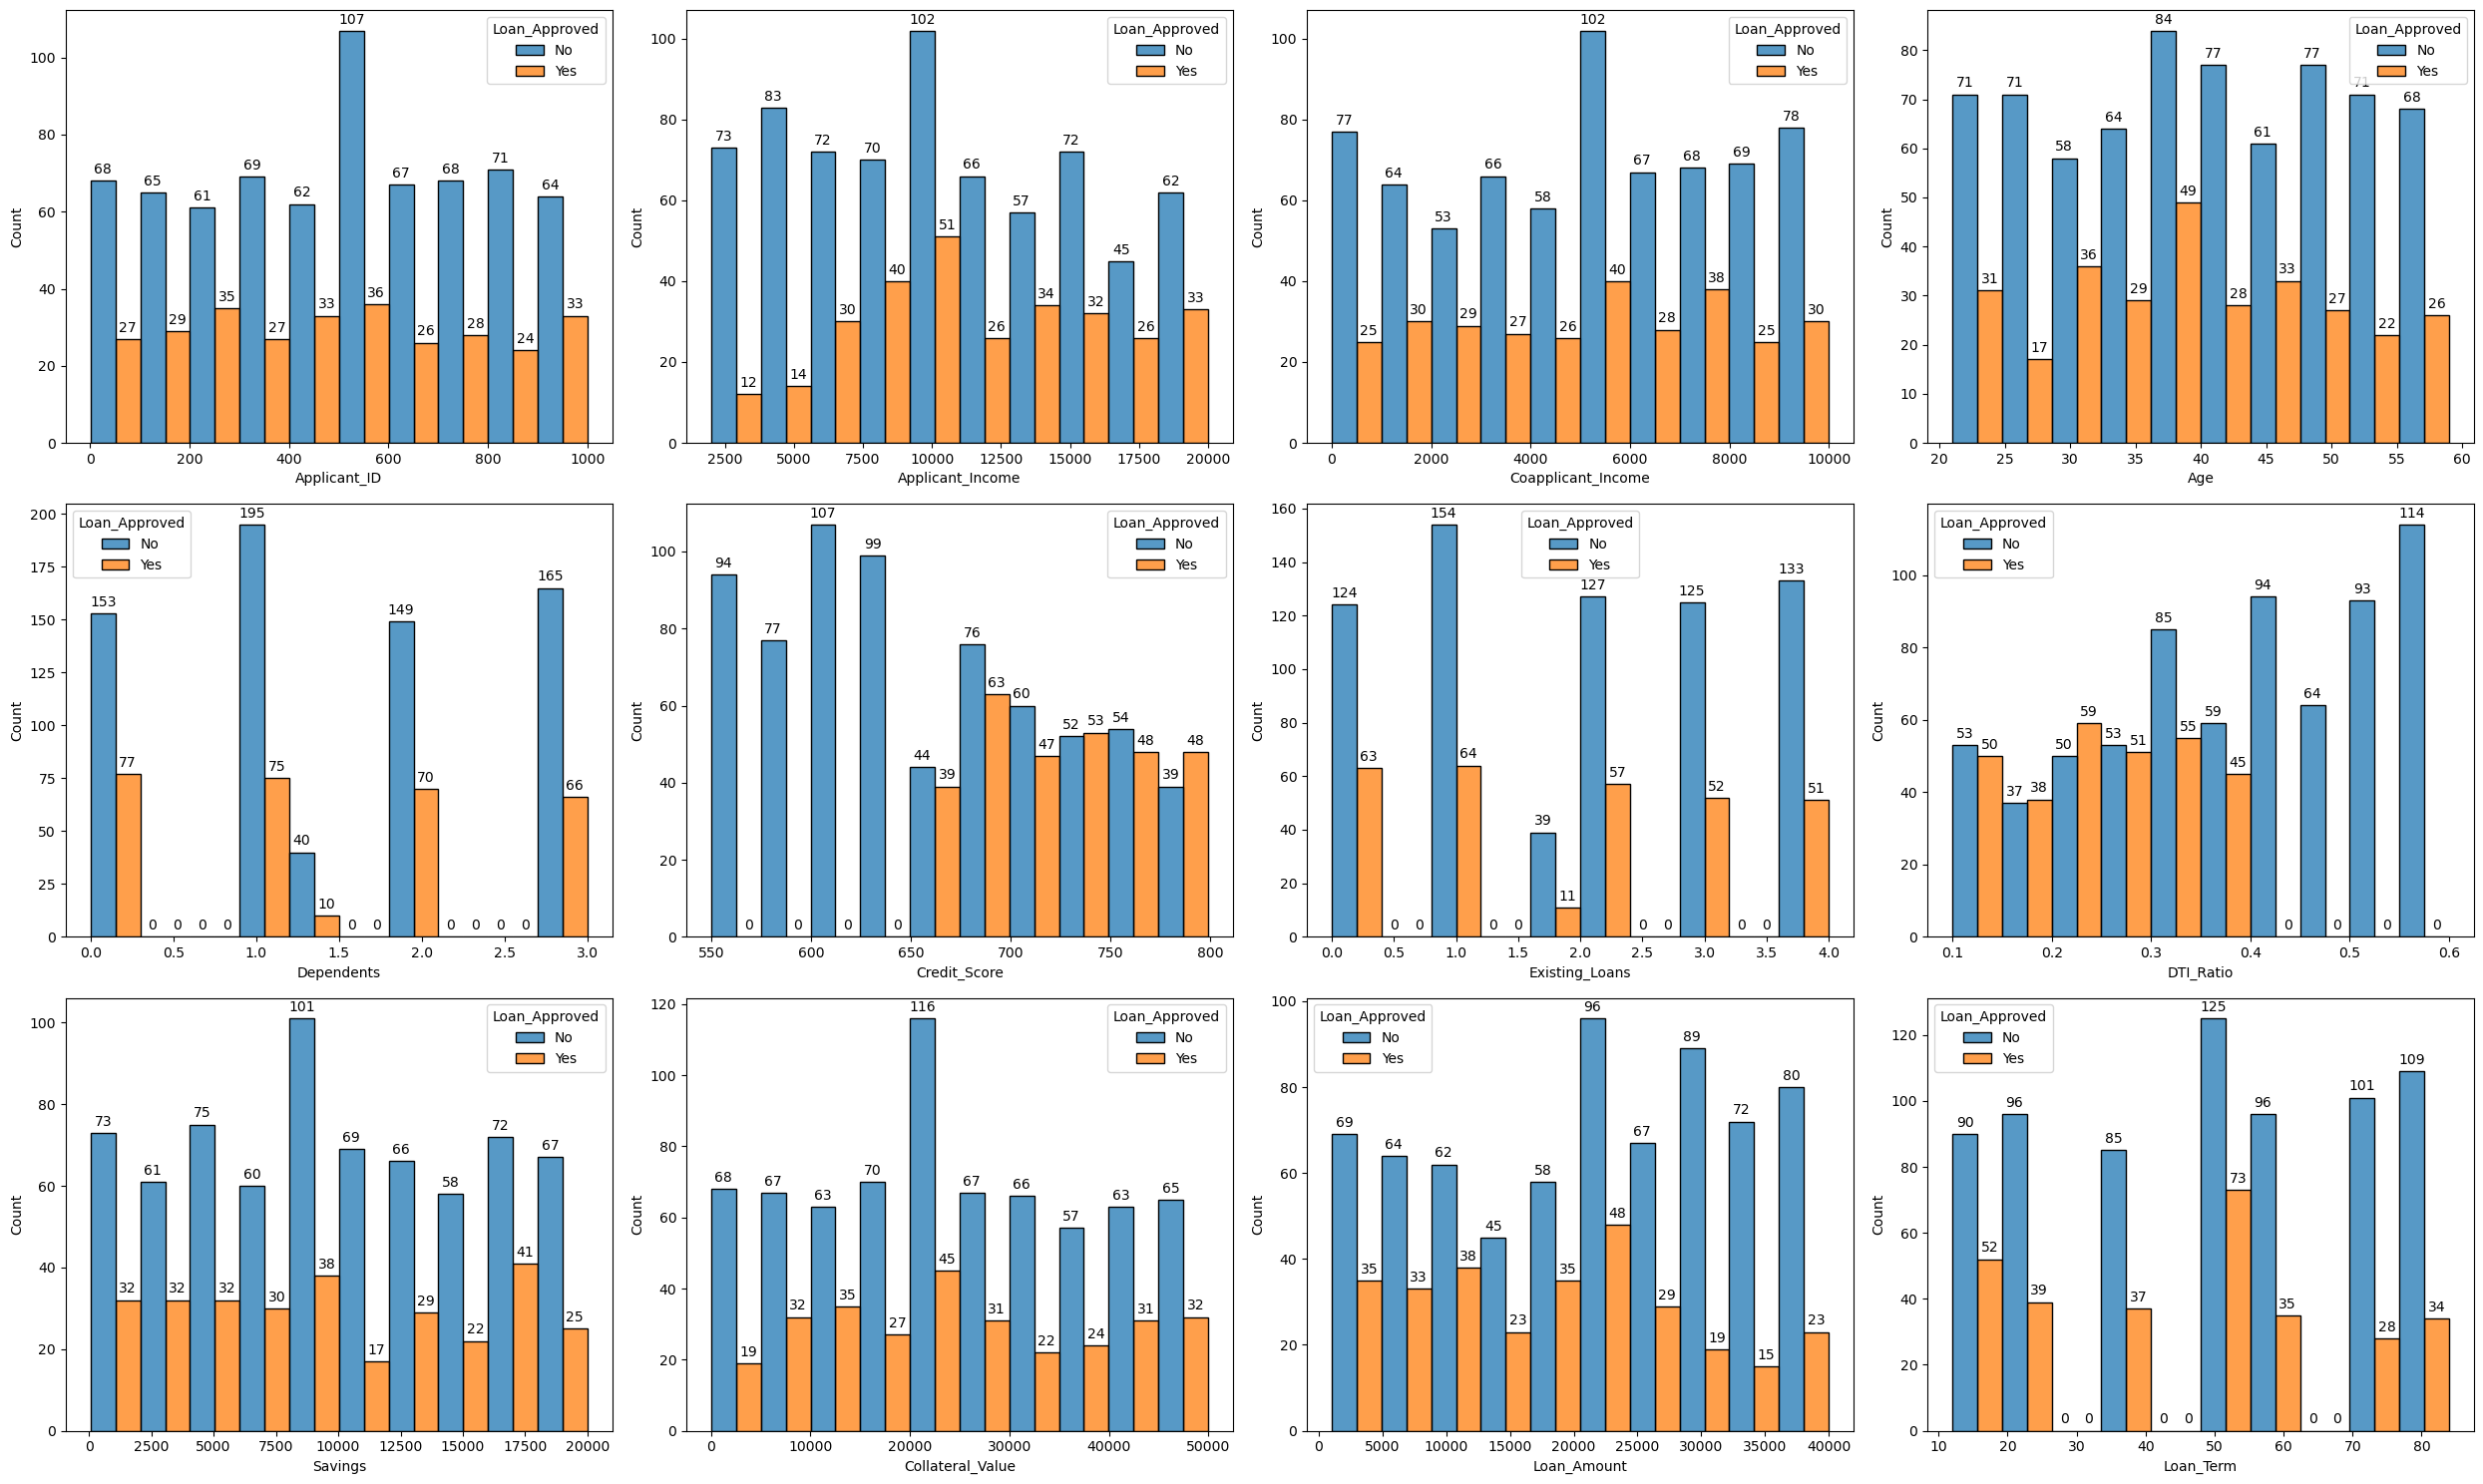

In [6]:
fig, axes = plt.subplots(3,4,figsize=(25,15))
for col,ax in zip(numerical_cols, axes.flat):
    sns.histplot(ax=ax, data=df, x = col, bins=10, hue="Loan_Approved", multiple="dodge")

    for container in ax.containers:
        ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

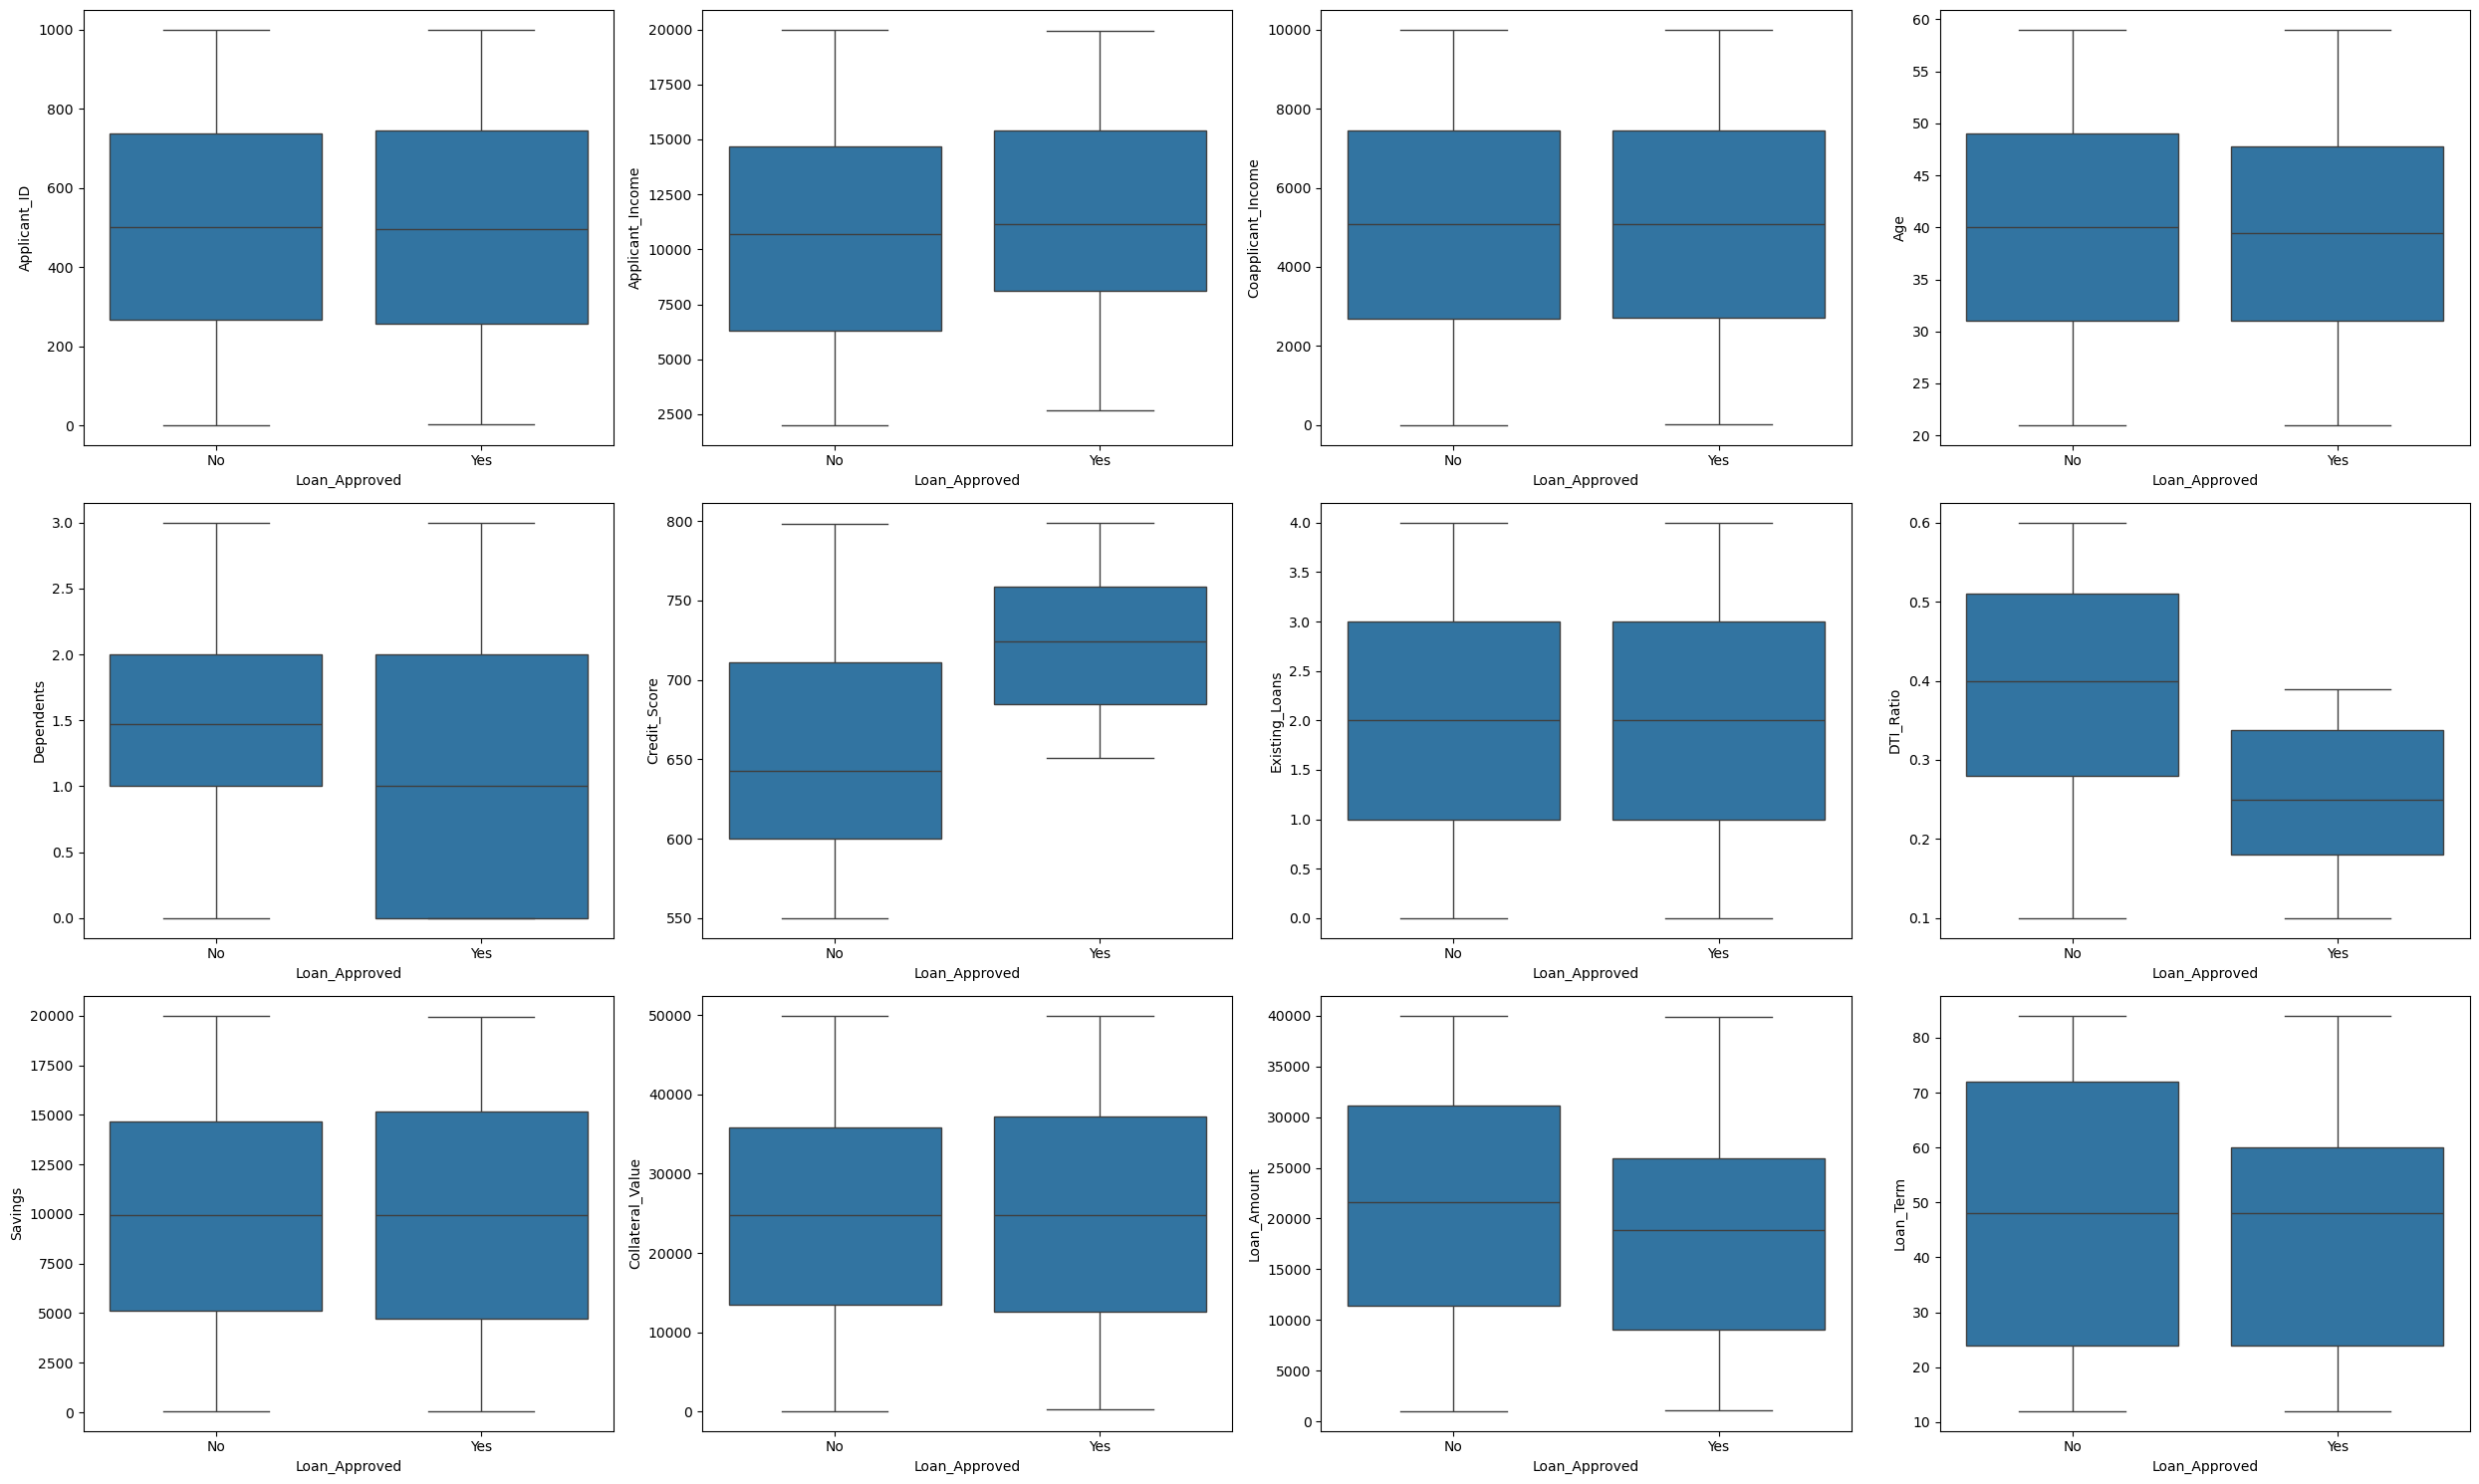

In [7]:
fig, axes = plt.subplots(3,4,figsize=(25,15))
for col,ax in zip(numerical_cols, axes.flat):
    sns.boxplot(ax=ax, data=df, x="Loan_Approved", y=col)

plt.tight_layout()
plt.show()

In [8]:
# Remove Applicant id column
df = df.drop("Applicant_ID",axis=1)
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# Encoding

In [9]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le = LabelEncoder()
ohe = OneHotEncoder(drop="first",sparse_output=False, handle_unknown="ignore")

df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

cols = ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]
encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)
df = pd.concat([df.drop(cols,axis=1),encoded_df], axis=1)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

<Axes: >

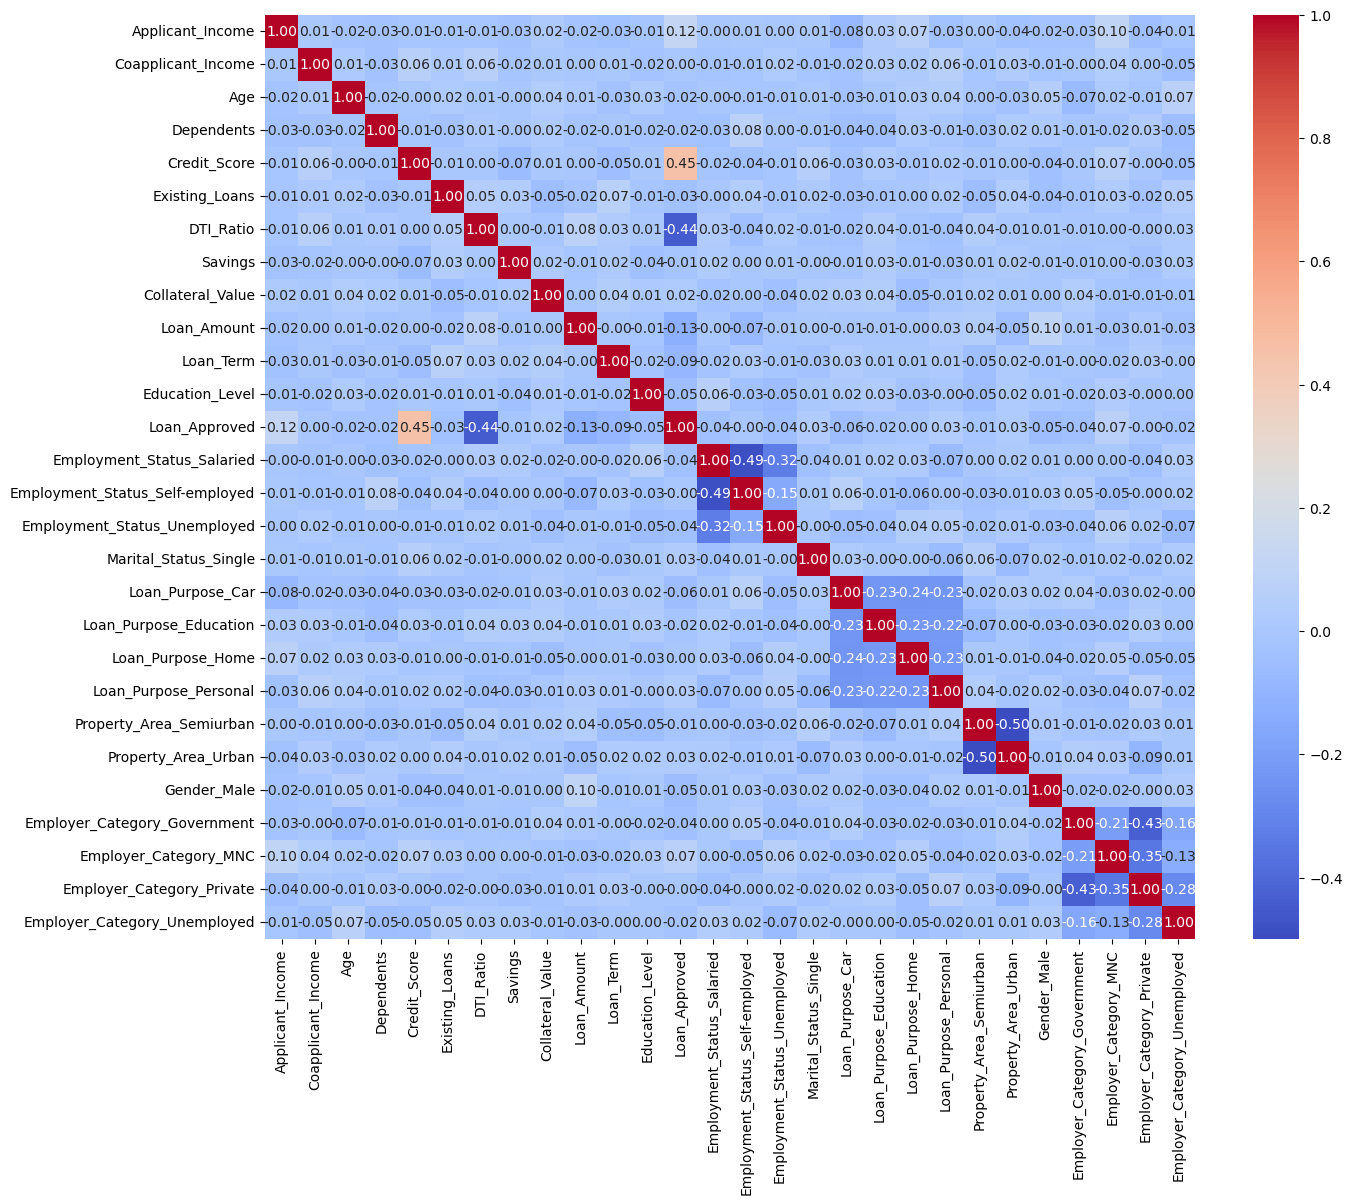

In [10]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()
corr_matrix["Loan_Approved"].sort_values(ascending=False)

plt.figure(figsize=(15,12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

# Train-Test-Split & Feature Scaling

In [11]:
X = df.drop("Loan_Approved",axis=1)
y = df["Loan_Approved"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
29,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,29287.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
535,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,14786.000000,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
695,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,20522.825263,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
557,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,13312.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
836,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,13906.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled

array([[-1.01234556e+00,  1.02716377e+00, -8.22511453e-01, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.23639141e+00, -1.59187898e+00,  9.15886794e-01, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.15862490e-02,  1.33606578e+00, -3.65038230e-01, ...,
        -4.13887756e-01,  1.16316000e+00, -3.07231582e-01],
       ...,
       [-2.27277589e-01,  3.50089621e-01, -8.22511453e-01, ...,
        -4.13887756e-01,  1.16316000e+00, -3.07231582e-01],
       [ 1.12970221e+00, -4.64700438e-01,  1.19037073e+00, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.75526629e+00,  1.43417276e-02,  9.40348249e-04, ...,
         2.41611400e+00, -8.59726954e-01, -3.07231582e-01]],
      shape=(800, 27))

# Train and Evaluate Model

In [13]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score,accuracy_score,recall_score, f1_score, confusion_matrix
lr = LogisticRegression()
lr.fit(X_train_scaled,y_train)
y_pred = lr.predict(X_test_scaled)

# Evaluation
print("Logistic Regression Model")
print("Precision : ", precision_score(y_test,y_pred))
print("Accuracy : ", accuracy_score(y_test,y_pred))
print("Recall : ", recall_score(y_test,y_pred))
print("F1 score : ", f1_score(y_test,y_pred))
print("Confusion Matrix : ", confusion_matrix(y_test,y_pred))

Logistic Regression Model
Precision :  0.7833333333333333
Accuracy :  0.865
Recall :  0.7704918032786885
F1 score :  0.7768595041322314
Confusion Matrix :  [[126  13]
 [ 14  47]]


In [14]:
# KNN Classifier
from sklearn.neighbors import KNeighborsClassifier
knn_classifier = KNeighborsClassifier(n_neighbors=17)
knn_classifier.fit(X_train_scaled,y_train)
y_pred = knn_classifier.predict(X_test_scaled)

# Evaluation
print("KNN model")
print("Precision : ", precision_score(y_test,y_pred))
print("Accuracy : ", accuracy_score(y_test,y_pred))
print("Recall : ", recall_score(y_test,y_pred))
print("F1 score : ", f1_score(y_test,y_pred))
print("Confusion Matrix : ", confusion_matrix(y_test,y_pred))

KNN model
Precision :  0.7352941176470589
Accuracy :  0.775
Recall :  0.4098360655737705
F1 score :  0.5263157894736842
Confusion Matrix :  [[130   9]
 [ 36  25]]


In [15]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train_scaled,y_train)
y_pred = nb_model.predict(X_test_scaled)

# Evaluation
print("Naive Bayes model")
print("Precision : ", precision_score(y_test,y_pred))
print("Accuracy : ", accuracy_score(y_test,y_pred))
print("Recall : ", recall_score(y_test,y_pred))
print("F1 score : ", f1_score(y_test,y_pred))
print("Confusion Matrix : ", confusion_matrix(y_test,y_pred))

Naive Bayes model
Precision :  0.8035714285714286
Accuracy :  0.865
Recall :  0.7377049180327869
F1 score :  0.7692307692307693
Confusion Matrix :  [[128  11]
 [ 16  45]]


# Best model on the basis of precision -> Naive Bayes

# Feature Engineering

In [31]:
df["DTI_Ratio_sq"] = df["DTI_Ratio"]**2
df["Credit_Score_sq"] = df["Credit_Score"]**2

# df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])
# X = df.drop(["Loan_Approved","DTI_Ratio","Credit_Score", "Applicant_Income"],axis=1)

X = df.drop(["Loan_Approved","DTI_Ratio","Credit_Score"],axis=1)

y = df["Loan_Approved"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [34]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score,accuracy_score,recall_score, f1_score, confusion_matrix
lr = LogisticRegression()
lr.fit(X_train_scaled,y_train)
y_pred = lr.predict(X_test_scaled)

# Evaluation
print("Logistic Regression Model")
print("Precision : ", precision_score(y_test,y_pred))
print("Accuracy : ", accuracy_score(y_test,y_pred))
print("Recall : ", recall_score(y_test,y_pred))
print("F1 score : ", f1_score(y_test,y_pred))
print("Confusion Matrix : ", confusion_matrix(y_test,y_pred))

Logistic Regression Model
Precision :  0.7846153846153846
Accuracy :  0.88
Recall :  0.8360655737704918
F1 score :  0.8095238095238095
Confusion Matrix :  [[125  14]
 [ 10  51]]


In [33]:
# KNN Classifier
from sklearn.neighbors import KNeighborsClassifier
knn_classifier = KNeighborsClassifier(n_neighbors=17)
knn_classifier.fit(X_train_scaled,y_train)
y_pred = knn_classifier.predict(X_test_scaled)

# Evaluation
print("KNN model")
print("Precision : ", precision_score(y_test,y_pred))
print("Accuracy : ", accuracy_score(y_test,y_pred))
print("Recall : ", recall_score(y_test,y_pred))
print("F1 score : ", f1_score(y_test,y_pred))
print("Confusion Matrix : ", confusion_matrix(y_test,y_pred))

KNN model
Precision :  0.7619047619047619
Accuracy :  0.805
Recall :  0.5245901639344263
F1 score :  0.6213592233009708
Confusion Matrix :  [[129  10]
 [ 29  32]]


In [32]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train_scaled,y_train)
y_pred = nb_model.predict(X_test_scaled)

# Evaluation
print("Naive Bayes model")
print("Precision : ", precision_score(y_test,y_pred))
print("Accuracy : ", accuracy_score(y_test,y_pred))
print("Recall : ", recall_score(y_test,y_pred))
print("F1 score : ", f1_score(y_test,y_pred))
print("Confusion Matrix : ", confusion_matrix(y_test,y_pred))

Naive Bayes model
Precision :  0.8113207547169812
Accuracy :  0.86
Recall :  0.7049180327868853
F1 score :  0.7543859649122807
Confusion Matrix :  [[129  10]
 [ 18  43]]


In [ ]:
### Final Model Selection Notes:
While Logistic Regression achieved the highest overall accuracy (88.0%) and recall (83.6%) after feature engineering, **Gaussian Naive Bayes remains our production model choice**. 

In credit underwriting, preventing False Positives (approving a defaulting applicant) is a higher business priority than maximizing recall. Naive Bayes delivers the highest **Precision (81.1%)**, making it the safest, most risk-averse model for protecting lending capital.